In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import json
from pathlib import Path
import random
from PIL import Image
import os
import sys
import io
import numpy as np
import torch
from omegaconf import OmegaConf
from torchvision import transforms

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

src_path = '/mnt/DATA2/dorin/Image-Transform-Predict/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.dataset import ImageTransformer
from src.dataset import TransformTokenizer
from src.dataset import DomainNetDataset
from src.dataset import NegativeImagePairDataset
from model import ImageTransformPredictor
from src.model import SiamNet


# plt.rcParams.update({
#     'text.usetex': False,
#     'font.family': 'serif',
#     'font.serif': ['DejaVu Serif'],  # ← Ключевое исправление
#     'font.size': 14,
#     'axes.labelsize': 14,
#     'axes.titlesize': 16,
#     'xtick.labelsize': 12,
#     'ytick.labelsize': 12,
#     'legend.fontsize': 12,
#     'lines.linewidth': 1.5,
#     'lines.markersize': 8,
#     'grid.alpha': 0.3,
#     'figure.dpi': 300,
#     'font.weight': 'normal',
# })

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet_pytorch
# !pip install --upgrade torchvision
# !pip install transformers==4.57.0
# !pip install qwen_vl_utils

In [3]:
src_path = '/mnt/DATA2/dorin/res.cv.science.dataset.generation/src'
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from pairwise_comparison_validation import RecallRobustnessEvaluator, plot_recall_robustness, FprEvaluator, plot_fpr_robustness
from categorization_visualization import plot_classification_histogram, DatasetSampler

### DomainNet Bench

In [11]:
from recall_fpr_bench import DomainRecallEvaluator, DomainFprEvaluator
from src.dataset import SimpleDomainNetDataset

In [12]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()

In [6]:
# path = "/mnt/DATA2/dorin/Image-Transform-Predict/data"
# data =  SimpleDomainNetDataset(path, split="val")

In [7]:
data.domain_distribution

{'clipart': 4812,
 'infograph': 5160,
 'painting': 7226,
 'quickdraw': 17250,
 'real': 17294,
 'sketch': 6912}

In [9]:
image, image_class = data[5000]
# image

In [6]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cuda', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cuda')
model.eval
print('ready')

def sim_fn_itp_vit(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    image_tensor_1 = image_tensor_1.to(next(model.parameters()).device)
    image_tensor_2 = image_tensor_2.to(next(model.parameters()).device)
        
    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.

    del image_tensor_1
    del image_tensor_2

    return similarity_score

ready


In [8]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model = ImageTransformPredictor(config.model)

# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cuda', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cuda')
model.eval()
print('ready')

# model.load_state_dict(torch.load('/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

def sim_fn_itp_effnet(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    image_tensor_1 = image_tensor_1.to(next(model.parameters()).device)
    image_tensor_2 = image_tensor_2.to(next(model.parameters()).device)
    
    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    del image_tensor_1
    del image_tensor_2

    return similarity_score

Loaded pretrained weights for efficientnet-b3
ready


In [10]:
import re
import torch

def sim_fn_qwen(img1, img2):
    was_training = model.training
    model.eval()
    
    try:
        messages = [{
            "role": "user",
            "content": [
                {"type": "image", "image": img1},
                {"type": "image", "image": img2},
                {"type": "text", "text": prompt_class_prediction},
            ],
        }]

        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.inference_mode():  # ← строже, чем no_grad
            generated_ids = model.generate(**inputs, max_new_tokens=128)

        # Извлечение текста
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
        ]
        output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0].strip()

        # === КРИТИЧЕСКАЯ ОЧИСТКА ===
        del generated_ids_trimmed
        del generated_ids
        del inputs
        del image_inputs
        del video_inputs
        del messages
        del text

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        match = re.fullmatch(r'[01]', output_text)
        if match:
            return float(match.group(0))
        else:
            raise ValueError(f"Unexpected model output: '{output_text}'. Expected '0' or '1'.")

    finally:
        if was_training:
            model.train()

In [16]:
# import torch.nn as nn
# from efficientnet_pytorch import EfficientNet
# import torch.nn.functional as F

# class SiamNet(nn.Module):
#     def __init__(self):
#         super(SiamNet, self).__init__()
#         self.extractor = EfficientNet.from_pretrained('efficientnet-b3')
#         del self.extractor._fc

#         self.dropf = nn.Dropout(p=0.20)
#         self.fc1 = nn.Linear(1536,1536)
#         self.drop1 = nn.Dropout(p=0.20)
#         self.fc2 = nn.Linear(1536,1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, batch1: torch.Tensor, batch2: torch.Tensor) -> torch.Tensor:
#         # Get embeddings for both batches
#         emb1 = self.get_q(batch1)
#         emb2 = self.get_q(batch2)

#         # Create all possible combinations of embeddings
#         batch_size1, emb_dim = emb1.size(0), emb1.size(1)
#         batch_size2 = emb2.size(0)

#         emb1_expanded = emb1.unsqueeze(1).expand(-1, batch_size2, -1)
#         emb2_expanded = emb2.unsqueeze(0).expand(batch_size1, -1, -1)

#         # dim: batch_size1 x batch_size2 x emb_dim
#         combined_embeddings = torch.abs(emb1_expanded - emb2_expanded)
#         combined_embeddings = combined_embeddings.view(-1, emb_dim)

#         # Get logits
#         logits = self.head_model(combined_embeddings)

#         # Reshape logits to form a batch_size1 x batch_size2 matrix
#         logits = logits.view(batch_size1, batch_size2)

#         return logits

#     def head_model(self, combined_embeddings):
#         r = self.drop1(F.relu(self.fc1(combined_embeddings)))
#         r = self.sigmoid(self.fc2(r))
#         return r
    
#     def forward_original(self, query, target, input_q=None, input_t=None, return_vectors=False):
#         b = query.size(0)
#         if input_q is None:
#             q = self.extractor._conv_stem(query)
#             q = self.extractor._bn0(q)
#             for k,lay in enumerate(self.extractor._blocks):
#                 q = lay(q)
#             q = self.extractor._conv_head(q)
#             q = self.extractor._bn1(q)
#             q = self.extractor._avg_pooling(q).view(b,-1)
#             q = self.dropf(q)
#         else:
#             q = input_q

#         if input_t is None:
#             t = self.extractor._conv_stem(target)
#             t = self.extractor._bn0(t)
#             for k,lay in enumerate(self.extractor._blocks):
#                 t = lay(t)
#             t = self.extractor._conv_head(t)
#             t = self.extractor._bn1(t)
#             t = self.extractor._avg_pooling(t).view(b,-1)
#             t = self.dropf(t)
#         else:
#             t = input_t

#         r = torch.abs(q-t)
#         r = self.drop1(F.relu(self.fc1(r)))
#         r = self.sigmoid(self.fc2(r))
#         if return_vectors:
#             return r, (q, t)
#         else:
#             return r

#     def get_q(self, query):
#         b = query.size(0)
#         q = self.extractor._conv_stem(query)
#         q = self.extractor._bn0(q)
#         for k,lay in enumerate(self.extractor._blocks):
#             q = lay(q)
#         q = self.extractor._conv_head(q)
#         q = self.extractor._bn1(q)
#         q = self.extractor._avg_pooling(q).view(b,-1)
#         q = self.dropf(q)
#         return q

In [7]:
model = SiamNet()

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

state_dict = torch.load("/mnt/DATA2/dorin/weights/vectorcomparator/OriginalModel/NewEfficentNetB3.pth", map_location="cpu")  # или "cuda"
model.load_state_dict(state_dict, strict=True)

model.to('cuda')
model.eval()
print('ready')


def sim_fn_siamnet(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    image_tensor_1 = image_tensor_1.to(next(model.parameters()).device)
    image_tensor_2 = image_tensor_2.to(next(model.parameters()).device)
    
    similarity_score = model(image_tensor_1, image_tensor_2).item()
    
    del image_tensor_1
    del image_tensor_2

    return similarity_score

Loaded pretrained weights for efficientnet-b3
ready


In [8]:
# image_1 = Image.open("/mnt/DATA2/dorin/imgs/animals/dog_1.jpg")
# image_2 = Image.open("/mnt/DATA2/dorin/imgs/animals/dog_2.jpg")

image_1 = Image.open("/mnt/DATA2/dorin/imgs/car/image1.jpg")
image_2 = Image.open("/mnt/DATA2/dorin/imgs/car/image2.jpg")

In [9]:
sim_fn_siamnet(image_1, image_2)

0.19115614891052246

In [17]:
input_1 = torch.rand(1, 3, 224, 224).to('cuda')

similarity_score = siamnet(input_1, input_1)
similarity_score.item()

0.9996182918548584

In [13]:
evaluator = DomainRecallEvaluator(
    data_dir="/mnt/DATA2/dorin/Image-Transform-Predict/data",
    sim_fn=sim_fn_siamnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

# results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (ViT-B/16) before sft", output_path = "recall_domainnet.json")

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Siamese Network", output_path = "/mnt/DATA2/dorin/Image-Transform-Predict/recall_domainnet.json")

Domain: clipart | N = 1000
  color_jitter    --> recall = 0.982
  crop            --> recall = 0.780
  crop_colorjitter_flipv --> recall = 0.288
  flip_vertical   --> recall = 0.714
  fliph_rot270_grayscale --> recall = 0.166
  grayscale       --> recall = 0.912
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 0.620
  rotate_90       --> recall = 0.247


Domain: infograph | N = 1000
  color_jitter    --> recall = 0.981
  crop            --> recall = 0.677
  crop_colorjitter_flipv --> recall = 0.223
  flip_vertical   --> recall = 0.775
  fliph_rot270_grayscale --> recall = 0.051
  grayscale       --> recall = 0.869
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 0.643
  rotate_90       --> recall = 0.100


Domain: painting | N = 1000
  color_jitter    --> recall = 0.976
  crop            --> recall = 0.686
  crop_colorjitter_flipv --> recall = 0.160
  flip_vertical   --> recall = 0.637
  fliph_rot270_grayscale --> recall = 0.043
  grayscale       --> recall = 0.779
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 0.469
  rotate_90       --> recall = 0.138


Domain: quickdraw | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.867
  crop_colorjitter_flipv --> recall = 0.510
  flip_vertical   --> recall = 0.752
  fliph_rot270_grayscale --> recall = 0.299
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 0.718
  rotate_90       --> recall = 0.302


Domain: real | N = 1000
  color_jitter    --> recall = 0.989
  crop            --> recall = 0.711
  crop_colorjitter_flipv --> recall = 0.243
  flip_vertical   --> recall = 0.655
  fliph_rot270_grayscale --> recall = 0.101
  grayscale       --> recall = 0.883
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 0.523
  rotate_90       --> recall = 0.171


Domain: sketch | N = 1000
  color_jitter    --> recall = 0.976
  crop            --> recall = 0.704
  crop_colorjitter_flipv --> recall = 0.256
  flip_vertical   --> recall = 0.674
  fliph_rot270_grayscale --> recall = 0.154
  grayscale       --> recall = 0.975
  jpeg_artefacts  --> recall = 0.999
  rotate_180      --> recall = 0.524
  rotate_90       --> recall = 0.173

Saved domain recall for 'Siamese Network' to '/mnt/DATA2/dorin/Image-Transform-Predict/recall_domainnet.json'


In [14]:
evaluator = DomainFprEvaluator(
    data_dir="/mnt/DATA2/dorin/Image-Transform-Predict/data",
    sim_fn=sim_fn_siamnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=4000, threshold=0.5, model_name = "Siamese Network", output_path = "/mnt/DATA2/dorin/Image-Transform-Predict/fpr_domainnet.json")

Domains:  17%|█▋        | 1/6 [13:58<1:09:52, 838.44s/it]

Domain: clipart | N = 4000 | FPR = 32/4000 = 0.008


Domains:  33%|███▎      | 2/6 [33:05<1:08:00, 1020.07s/it]

Domain: infograph | N = 4000 | FPR = 0/4000 = 0.000


Domains:  50%|█████     | 3/6 [56:19<59:32, 1190.93s/it]  

...

Domain: quickdraw | N = 4000 | FPR = 0/4000 = 0.000


Domains:  83%|████████▎ | 5/6 [1:37:03<19:36, 1176.53s/it]

Domain: real | N = 4000 | FPR = 2/4000 = 0.001


Domains: 100%|██████████| 6/6 [1:40:57<00:00, 1009.52s/it]

Domain: sketch | N = 4000 | FPR = 11/4000 = 0.003

Saved domain FPR for 'Siamese Network' to '/mnt/DATA2/dorin/Image-Transform-Predict/fpr_domainnet.json'


Примеры негативных пар (разные изображения из одного домена):

Domain: clipart
  → clipart_train_027302.jpg
  → clipart_test_007297.jpg


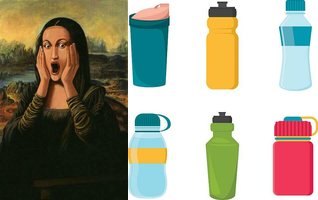

--------------------------------------------------
Domain: infograph
  → infograph_train_001542.jpg
  → infograph_train_034607.jpg


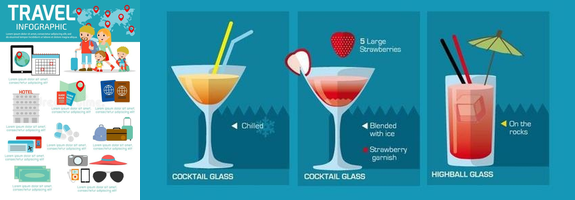

--------------------------------------------------
Domain: painting
  → painting_train_024850.jpg
  → painting_train_017093.jpg


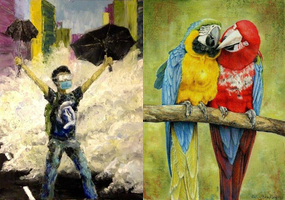

--------------------------------------------------
Domain: quickdraw
  → quickdraw_train_001308.jpg
  → quickdraw_train_110890.jpg


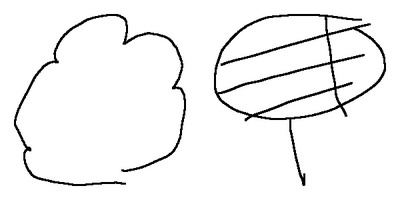

--------------------------------------------------
Domain: real
  → real_test_029182.jpg
  → real_train_085785.jpg


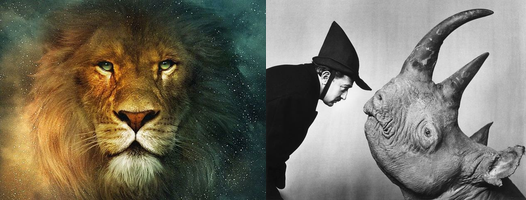

--------------------------------------------------
Domain: sketch
  → sketch_test_002264.jpg
  → sketch_test_007900.jpg


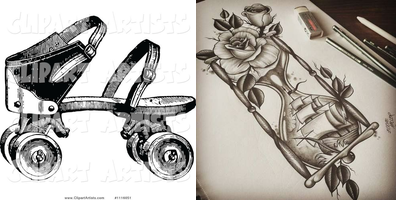

--------------------------------------------------


In [15]:
from pathlib import Path
import random
import os
from PIL import Image
from IPython.display import display

# Параметры — должны совпадать с вашим evaluator'ом
data_dir = "/mnt/DATA2/dorin/Image-Transform-Predict/data"
val_size = 0.1
split_random_seed = 42

# Загрузка val-сплита (как в evaluator'е)
domain_to_val_paths = {}
rng = random.Random(split_random_seed)

for domain in sorted(os.listdir(data_dir)):
    domain_path = Path(data_dir) / domain
    if not domain_path.is_dir():
        continue
    all_paths = []
    for file in sorted(domain_path.iterdir()):
        if file.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            all_paths.append(file)
    if not all_paths:
        continue
    shuffled = rng.sample(all_paths, len(all_paths))
    n_val = int(len(shuffled) * val_size)
    val_paths = shuffled[:n_val]
    if len(val_paths) >= 2:
        domain_to_val_paths[domain] = val_paths

# Генерация и отображение одной пары на домен
print("Примеры негативных пар (разные изображения из одного домена):\n")

for domain, paths in sorted(domain_to_val_paths.items()):
    p1, p2 = paths[0], paths[1]
    
    print(f"Domain: {domain}")
    print(f"  → {p1.name}")
    print(f"  → {p2.name}")
    
    # Загружаем и отображаем изображения рядом
    img1 = Image.open(p1).convert("RGB")
    img2 = Image.open(p2).convert("RGB")
    
    # Опционально: привести к одинаковой высоте для аккуратного отображения
    max_height = 200
    def resize_to_height(img, h):
        w = int(img.width * h / img.height)
        return img.resize((w, h), Image.LANCZOS)
    
    img1_r = resize_to_height(img1, max_height)
    img2_r = resize_to_height(img2, max_height)
    
    # Объединяем изображения горизонтально
    combined_width = img1_r.width + img2_r.width
    combined = Image.new('RGB', (combined_width, max_height))
    combined.paste(img1_r, (0, 0))
    combined.paste(img2_r, (img1_r.width, 0))
    
    display(combined)
    print("-" * 50)

### Negative Bench

#### Analysis of the test sample

In [22]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()
batch_names = [
    "dataset_0", "dataset_1", "dataset_5", "dataset_9",
    "dataset_2", "dataset_18", "dataset_27", "dataset_36",
    "dataset_45", "dataset_270", "dataset_281", "dataset_150",
    "dataset_180"
]

negative_data = NegativeImagePairDataset(
        root_dir = "/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
        batch_names = batch_names,
        transformer = transformer,
        tokenizer = tokenizer,
        split = "val",
        val_size = 0.1,
        random_seed = 42,
        max_seq_len = 15,
        augmentation_p = 0.3
)

In [23]:
len(negative_data._pairs_and_meta)

69174

In [2]:
category_to_pairs = {}
dataset_root = Path("/mnt/DATA2/dorin/res.cv.science.dataset.generation")

In [42]:
def load_pairs(json_path: str) -> None:
    with open(json_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    for entry in metadata:
        c1 = entry.get("image_1_class")
        c2 = entry.get("image_2_class")
        if not (c1 and c2 and c1 == c2):
            continue  # skip cross-domain or missing classes

        p1 = dataset_root / entry["batch_name"] / "dataset" / entry["image_1"]
        p2 = dataset_root / entry["batch_name"] / "dataset" / entry["image_2"]
        category_to_pairs.setdefault(c1, []).append((p1, p2))

In [43]:
load_pairs("/mnt/DATA2/dorin/Image-Transform-Predict/negative_test_dataset_meta.json")

In [49]:
for cat in category_to_pairs.keys():
    print(cat, len(category_to_pairs[cat]))

text 5768
microscopy 23193
monotone 2670
diagram 2938
medical 3128
hand_drawn 215
other 6681
photo 400
face 384


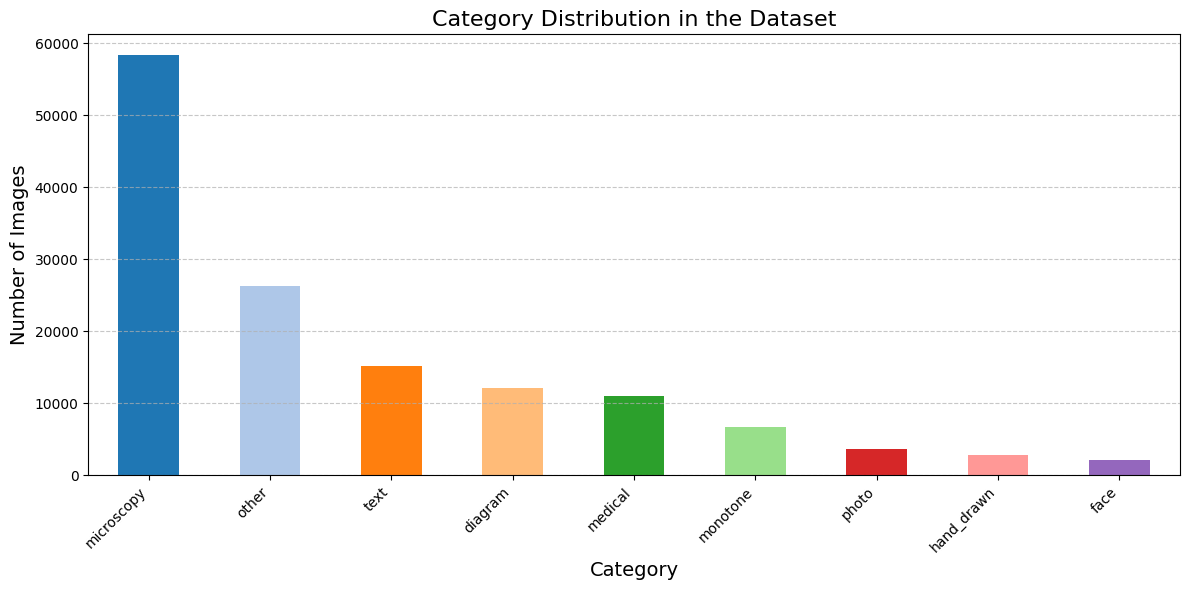

In [7]:
plot_classification_histogram("/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json")

In [10]:
sampler = DatasetSampler("/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets", "/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json")

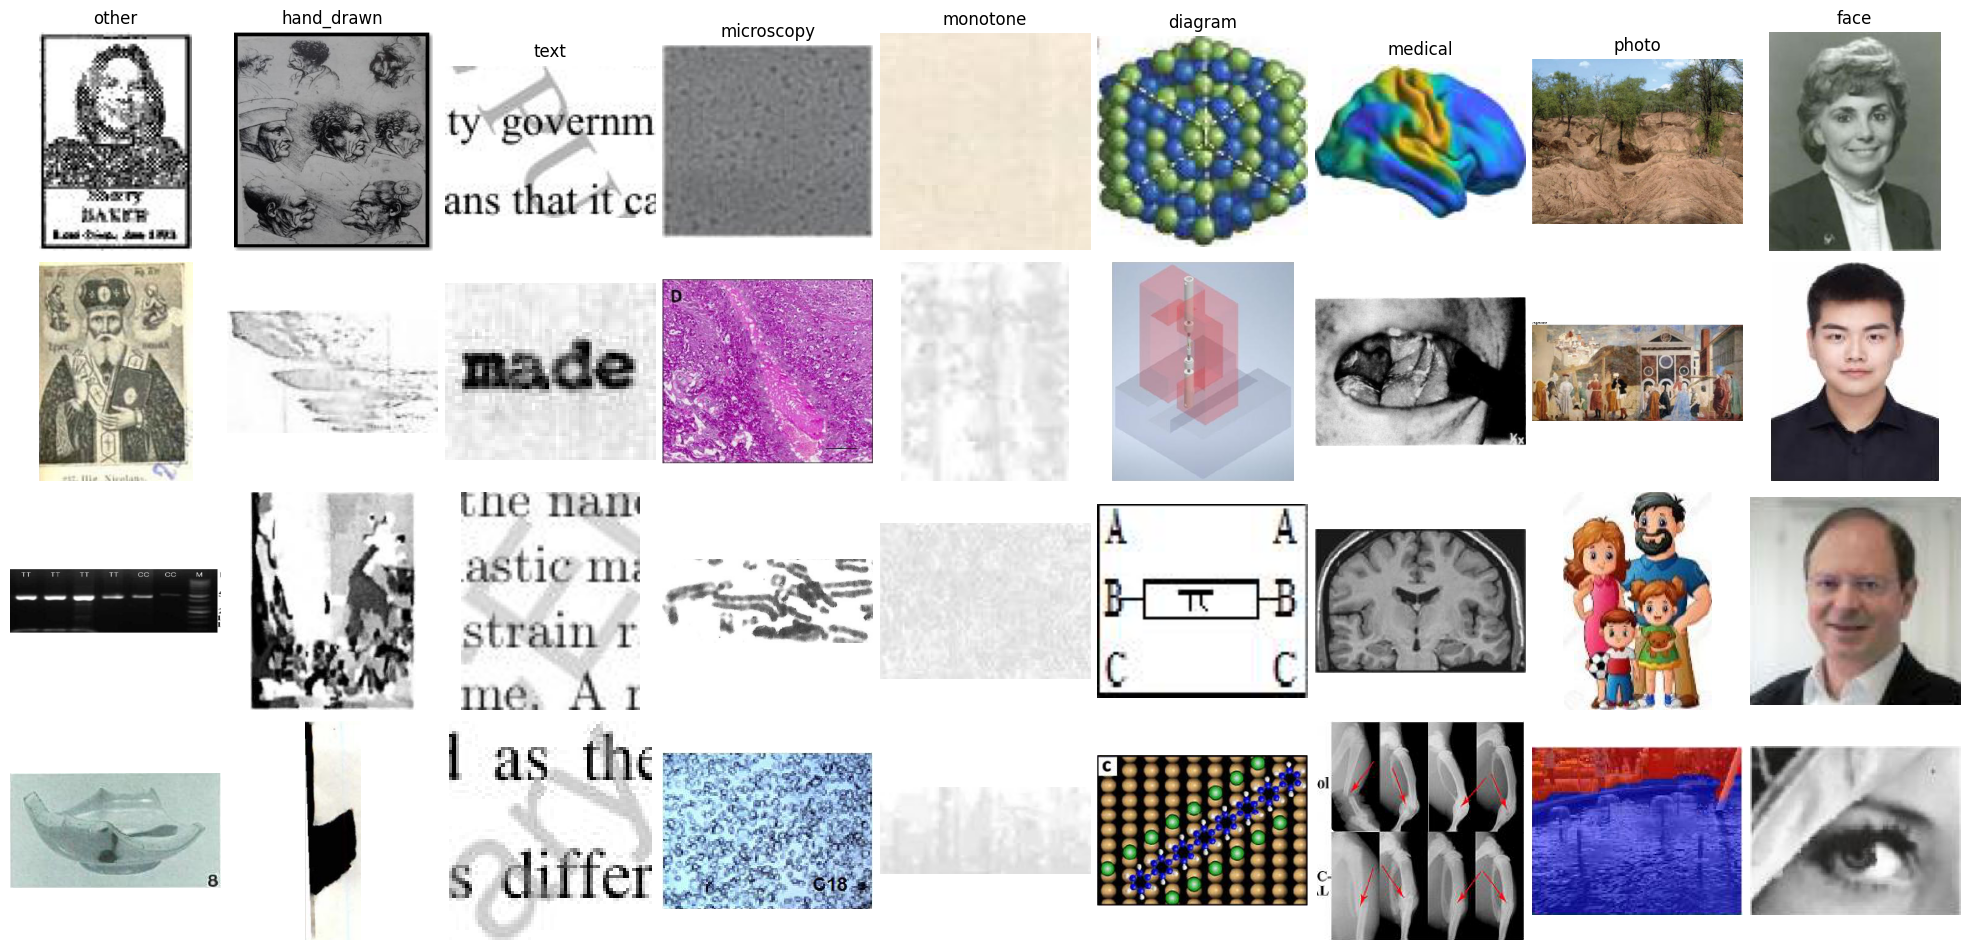

In [11]:
sampler.sample_and_display()

#### Evaluation of sequence prediction models (ViT based, EfficientNet based)

In [3]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_011.yaml')
model = ImageTransformPredictor(config.model)

# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/checkpoint_epoch_50.pth'
checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011_tune_full/checkpoint_epoch_15.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cuda')
model.eval()
print('ready')

# model.load_state_dict(torch.load('/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_011/model_weights.pth'))
# model.to('cpu')
# model.eval()
# print('ready')

def sim_fn_itp_effnet(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0).to('cuda')
    image_tensor_2 = preprocess(img2).unsqueeze(0).to('cuda')

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    del image_tensor_1, image_tensor_2, generated
    return similarity_score

Loaded pretrained weights for efficientnet-b3
ready


In [1]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

config = OmegaConf.load('/mnt/DATA2/dorin/Image-Transform-Predict/configs/train_config_vit.yaml')
model = ImageTransformPredictor(config.model)

checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit/checkpoint_epoch_100.pth'
# checkpoint_path = '/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

def sim_fn_itp_vit(img1, img2):
    image_tensor_1 = preprocess(img1).unsqueeze(0)
    image_tensor_2 = preprocess(img2).unsqueeze(0)

    generated = model.generate(image_tensor_1, image_tensor_2, max_new_tokens=10, do_sample=False)
    if generated[0][1] == 2: # выдало пустую последовательность
        similarity_score = 0.
    else:
        similarity_score = 1.
    del image_tensor_1, image_tensor_2, generated
    return similarity_score

In [6]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_effnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3) before sft", output_path = "recall_negative_dataset.json")

 11%|█         | 1/9 [05:04<40:35, 304.43s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.997
  crop            --> recall = 0.967
  crop_colorjitter_flipv --> recall = 0.893
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.996
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 22%|██▏       | 2/9 [10:06<35:20, 302.93s/it]

Category: face | N = 1000
  color_jitter    --> recall = 0.997
  crop            --> recall = 0.977
  crop_colorjitter_flipv --> recall = 0.920
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.997
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 33%|███▎      | 3/9 [15:39<31:40, 316.83s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.999
  crop            --> recall = 0.962
  crop_colorjitter_flipv --> recall = 0.911
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.997
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 89%|████████▉ | 8/9 [42:11<05:27, 327.37s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 0.997
  crop            --> recall = 0.977
  crop_colorjitter_flipv --> recall = 0.907
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 1.000
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


100%|██████████| 9/9 [47:20<00:00, 315.63s/it]

Category: text | N = 1000
  color_jitter    --> recall = 1.000
  crop            --> recall = 0.985
  crop_colorjitter_flipv --> recall = 0.962
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.998
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000

Saved results for 'ours (EfficientNet-B3) before sft' to 'recall_negative_dataset.json'


In [4]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_effnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3)", output_path = "recall_negative_dataset.json")

 11%|█         | 1/9 [04:44<37:56, 284.56s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.997
  crop            --> recall = 0.930
  crop_colorjitter_flipv --> recall = 0.832
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 0.999
  jpeg_artefacts  --> recall = 0.971
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 22%|██▏       | 2/9 [09:33<33:29, 287.09s/it]

Category: face | N = 1000
  color_jitter    --> recall = 0.998
  crop            --> recall = 0.929
  crop_colorjitter_flipv --> recall = 0.861
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.981
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 33%|███▎      | 3/9 [14:56<30:21, 303.60s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.995
  crop            --> recall = 0.950
  crop_colorjitter_flipv --> recall = 0.867
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.993
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


 89%|████████▉ | 8/9 [41:13<05:20, 320.93s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 0.999
  crop            --> recall = 0.956
  crop_colorjitter_flipv --> recall = 0.882
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.991
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000


100%|██████████| 9/9 [46:18<00:00, 308.76s/it]

Category: text | N = 1000
  color_jitter    --> recall = 0.999
  crop            --> recall = 0.900
  crop_colorjitter_flipv --> recall = 0.811
  flip_vertical   --> recall = 1.000
  fliph_rot270_grayscale --> recall = 1.000
  grayscale       --> recall = 1.000
  jpeg_artefacts  --> recall = 0.985
  rotate_180      --> recall = 1.000
  rotate_90       --> recall = 1.000

Saved results for 'ours (EfficientNet-B3)' to 'recall_negative_dataset.json'


In [8]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_effnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (EfficientNet-B3) before sft", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [03:10<25:24, 190.57s/it]

Domain: diagram | N = 1000 | FPR = 68/1000 = 0.068


Domains:  22%|██▏       | 2/9 [04:13<13:27, 115.31s/it]

Domain: face | N = 384 | FPR = 69/384 = 0.180


Domains:  33%|███▎      | 3/9 [04:58<08:20, 83.47s/it] 

...

Domain: other | N = 1000 | FPR = 58/1000 = 0.058


Domains:  89%|████████▉ | 8/9 [19:23<02:32, 152.40s/it]

Domain: photo | N = 400 | FPR = 27/400 = 0.068


Domains: 100%|██████████| 9/9 [22:16<00:00, 148.52s/it]

Domain: text | N = 1000 | FPR = 336/1000 = 0.336

Saved domain-wise FPR for 'ours (EfficientNet-B3) before sft' to 'fpr_negative_dataset.json'


In [9]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_itp_vit,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "ours (ViT-B/16) before sft", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [03:25<27:26, 205.81s/it]

Domain: diagram | N = 1000 | FPR = 68/1000 = 0.068


Domains:  22%|██▏       | 2/9 [04:42<15:09, 129.90s/it]

Domain: face | N = 384 | FPR = 69/384 = 0.180


Domains:  33%|███▎      | 3/9 [05:37<09:32, 95.50s/it] 

...

Domain: other | N = 1000 | FPR = 58/1000 = 0.058


Domains:  89%|████████▉ | 8/9 [22:27<03:04, 184.27s/it]

Domain: photo | N = 400 | FPR = 27/400 = 0.068


Domains: 100%|██████████| 9/9 [27:13<00:00, 181.51s/it]

Domain: text | N = 1000 | FPR = 336/1000 = 0.336

Saved domain-wise FPR for 'ours (ViT-B/16) before sft' to 'fpr_negative_dataset.json'


#### Comparison with Qwen3-VL-4B-Instruct in the task of predicting the transformation sequence

In [3]:
# !pip install transformers==4.57.0
# !pip install qwen_vl_utils

In [4]:
import torch

from transformers import AutoTokenizer, AutoProcessor
from transformers import Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info
from PIL import Image

if not hasattr(torch.compiler, "is_compiling"):
    torch.compiler.is_compiling = lambda: False

In [5]:
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
)

# Store processor for preprocessing
processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model.to("cuda")
print("ready")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

ready


In [7]:
prompt_class_prediction = """You are an expert in image forensics. Determine whether Image B is a plagiarized version of Image A, meaning it was obtained by applying only the following allowed transformations to Image A:  
- Geometric: rotate_90, rotate_180, rotate_270, horizontal_flip, vertical_flip  
- Photometric: grayscale, color_jitter  
- Structural: crop  
- Noise/compression: noise_adding, jpeg_artefacts  

If Image B can be produced from Image A using any combination of these operations (in any order, without repetition), output 1.  
If Image B involves any other transformation (e.g., blur, resize, perspective warp, object removal, or unrelated content), output 0.

Output only a single digit: 1 or 0. Do not add any other text, explanation, or punctuation."""

['rotate_180', 'jpeg_artefacts']


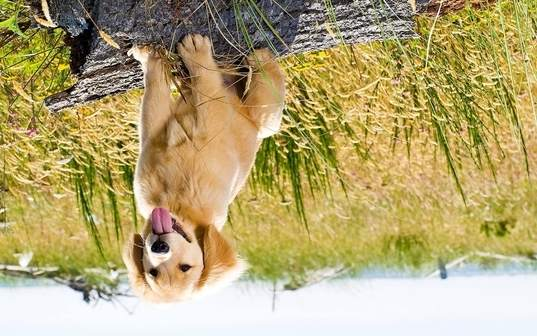

In [11]:
image = Image.open('../assets/dog.jpg')
image_car = Image.open('/mnt/DATA2/dorin/imgs/car/image1.jpg')
transformed_image, sequence = transformer.transform_by_length(image, 2)

print(sequence)
transformed_image.show()

In [12]:
import re
import torch

def sim_fn_qwen(img1, img2):
    # Ensure model is in eval mode to disable dropout, etc.
    was_training = model.training
    model.eval()
    
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img1},
            {"type": "image", "image": img2},
            {"type": "text", "text": prompt_class_prediction},
        ],
    }]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():  # critical: disable gradient tracking
        generated_ids = model.generate(**inputs, max_new_tokens=128)

    # Extract only the needed part
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()

    # Clean up GPU tensors immediately
    del inputs, generated_ids, generated_ids_trimmed
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # optional, but safe for long runs

    match = re.fullmatch(r'[01]', output_text)
    if match:
        return float(match.group(0))
    else:
        raise ValueError(f"Unexpected model output: '{output_text}'. Expected '0' or '1'.")

In [13]:
sim_fn_qwen(image, transformed_image)

0.0

In [14]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_qwen,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Qwen3-VL-4B", output_path = "recall_negative_dataset.json")

  0%|          | 0/9 [00:00<?, ?it/s]

[Score error] /mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets/dataset_5/dataset/009027696_2.png, rotate_90: CUDA out of memory. Tried to allocate 524.00 MiB. GPU 0 has a total capacity of 23.69 GiB of which 305.44 MiB is free. Process 860743 has 23.38 GiB memory in use. Of the allocated memory 22.32 GiB is allocated by PyTorch, and 778.73 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
[Score error] /mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets/dataset_5/dataset/009027696_2.png, rotate_180: CUDA out of memory. Tried to allocate 524.00 MiB. GPU 0 has a total capacity of 23.69 GiB of which 305.44 MiB is free. Process 860743 has 23.38 GiB memory in use. Of the allocated memory 22.35 GiB is allocated by PyTorch, and 746.42 MiB is rese

 11%|█         | 1/9 [1:04:44<8:37:56, 3884.59s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.742
  crop            --> recall = 0.893
  crop_colorjitter_flipv --> recall = 0.461
  flip_vertical   --> recall = 0.681
  fliph_rot270_grayscale --> recall = 0.535
  grayscale       --> recall = 0.920
  jpeg_artefacts  --> recall = 0.955
  rotate_180      --> recall = 0.749
  rotate_90       --> recall = 0.756


 22%|██▏       | 2/9 [1:49:30<6:10:55, 3179.41s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.807
  crop            --> recall = 0.955
  crop_colorjitter_flipv --> recall = 0.527
  flip_vertical   --> recall = 0.762
  fliph_rot270_grayscale --> recall = 0.749
  grayscale       --> recall = 0.985
  jpeg_artefacts  --> recall = 0.982
  rotate_180      --> recall = 0.765
  rotate_90       --> recall = 0.831


 89%|████████▉ | 8/9 [8:15:20<1:10:09, 4209.36s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 0.740
  crop            --> recall = 0.937
  crop_colorjitter_flipv --> recall = 0.342
  flip_vertical   --> recall = 0.571
  fliph_rot270_grayscale --> recall = 0.657
  grayscale       --> recall = 0.967
  jpeg_artefacts  --> recall = 0.965
  rotate_180      --> recall = 0.549
  rotate_90       --> recall = 0.778


100%|██████████| 9/9 [9:27:13<00:00, 3781.53s/it]  

Category: text | N = 1000
  color_jitter    --> recall = 0.986
  crop            --> recall = 0.969
  crop_colorjitter_flipv --> recall = 0.597
  flip_vertical   --> recall = 0.684
  fliph_rot270_grayscale --> recall = 0.664
  grayscale       --> recall = 0.994
  jpeg_artefacts  --> recall = 0.995
  rotate_180      --> recall = 0.699
  rotate_90       --> recall = 0.837

Saved results for 'Qwen3-VL-4B' to 'recall_negative_dataset.json'


In [21]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_qwen,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Qwen3-VL-4B", output_path = "fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [32:36<4:20:55, 1956.96s/it]

Domain: diagram | N = 1000 | FPR = 61/1000 = 0.061


Domains:  22%|██▏       | 2/9 [42:35<2:15:03, 1157.62s/it]

Domain: face | N = 384 | FPR = 40/384 = 0.104


Domains:  33%|███▎      | 3/9 [52:30<1:30:05, 900.95s/it] 

...

Domains:  89%|████████▉ | 8/9 [2:45:02<19:14, 1154.98s/it]

Domain: photo | N = 400 | FPR = 29/400 = 0.072


Domains: 100%|██████████| 9/9 [2:55:57<00:00, 1173.11s/it]

Domain: text | N = 1000 | FPR = 214/1000 = 0.214



Saved domain-wise FPR for 'Qwen3-VL-4B' to 'fpr_negative_dataset.json'


#### SiamNet

In [16]:
evaluator = FprEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_siamnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Siamese Network", output_path = "/mnt/DATA2/dorin/Image-Transform-Predict/fpr_negative_dataset.json")

Domains:  11%|█         | 1/9 [01:19<10:34, 79.29s/it]

Domain: diagram | N = 1000 | FPR = 0/1000 = 0.000


Domains:  22%|██▏       | 2/9 [01:46<05:39, 48.44s/it]

Domain: face | N = 384 | FPR = 0/384 = 0.000


Domains:  33%|███▎      | 3/9 [02:10<03:43, 37.24s/it]

...

Domain: other | N = 1000 | FPR = 0/1000 = 0.000


Domains:  89%|████████▉ | 8/9 [08:00<01:03, 63.36s/it]

Domain: photo | N = 400 | FPR = 0/400 = 0.000


Domains: 100%|██████████| 9/9 [09:08<00:00, 60.90s/it]

Domain: text | N = 1000 | FPR = 0/1000 = 0.000

Saved domain-wise FPR for 'Siamese Network' to '/mnt/DATA2/dorin/Image-Transform-Predict/fpr_negative_dataset.json'


In [17]:
evaluator = RecallRobustnessEvaluator(
    dataset_root="/mnt/DATA2/dorin/res.cv.science.dataset.generation/datasets",
    json_path="/mnt/DATA2/dorin/Image-Transform-Predict/benchmarking/negative_test_dataset_meta.json",
    sim_fn=sim_fn_siamnet,
    preprocess=None, # нужен если не вшит в sim_fn
    seed=2025
)

results = evaluator.evaluate(n_samples=1000, threshold=0.5, model_name = "Siamese Network", output_path = "/mnt/DATA2/dorin/Image-Transform-Predict/recall_negative_dataset.json")

 11%|█         | 1/9 [05:05<40:40, 305.09s/it]

Category: diagram | N = 1000
  color_jitter    --> recall = 0.943
  crop            --> recall = 0.763
  crop_colorjitter_flipv --> recall = 0.290
  flip_vertical   --> recall = 0.776
  fliph_rot270_grayscale --> recall = 0.104
  grayscale       --> recall = 0.775
  jpeg_artefacts  --> recall = 0.946
  rotate_180      --> recall = 0.639
  rotate_90       --> recall = 0.202


 22%|██▏       | 2/9 [09:54<34:29, 295.70s/it]

Category: face | N = 1000
  color_jitter    --> recall = 0.978
  crop            --> recall = 0.833
  crop_colorjitter_flipv --> recall = 0.412
  flip_vertical   --> recall = 0.652
  fliph_rot270_grayscale --> recall = 0.176
  grayscale       --> recall = 0.955
  jpeg_artefacts  --> recall = 0.936
  rotate_180      --> recall = 0.554
  rotate_90       --> recall = 0.211


 33%|███▎      | 3/9 [15:09<30:28, 304.82s/it]

...

Category: other | N = 1000
  color_jitter    --> recall = 0.976
  crop            --> recall = 0.714
  crop_colorjitter_flipv --> recall = 0.264
  flip_vertical   --> recall = 0.673
  fliph_rot270_grayscale --> recall = 0.074
  grayscale       --> recall = 0.903
  jpeg_artefacts  --> recall = 0.964
  rotate_180      --> recall = 0.522
  rotate_90       --> recall = 0.122


 89%|████████▉ | 8/9 [40:43<05:12, 312.99s/it]

Category: photo | N = 1000
  color_jitter    --> recall = 0.993
  crop            --> recall = 0.665
  crop_colorjitter_flipv --> recall = 0.178
  flip_vertical   --> recall = 0.543
  fliph_rot270_grayscale --> recall = 0.041
  grayscale       --> recall = 0.895
  jpeg_artefacts  --> recall = 0.969
  rotate_180      --> recall = 0.372
  rotate_90       --> recall = 0.066


100%|██████████| 9/9 [45:42<00:00, 304.75s/it]

Category: text | N = 1000
  color_jitter    --> recall = 0.893
  crop            --> recall = 0.661
  crop_colorjitter_flipv --> recall = 0.252
  flip_vertical   --> recall = 0.790
  fliph_rot270_grayscale --> recall = 0.052
  grayscale       --> recall = 0.990
  jpeg_artefacts  --> recall = 0.924
  rotate_180      --> recall = 0.654
  rotate_90       --> recall = 0.062

Saved results for 'Siamese Network' to '/mnt/DATA2/dorin/Image-Transform-Predict/recall_negative_dataset.json'
